In [1]:
# WorkFlow

# Dataset
#    ↓
# Explore data
#    ↓
# Create PyTorch Dataset
#    ↓
# Preprocess images
#    ↓
# Load ResNet18
#    ↓
# Train model
#    ↓
# Validate model
#    ↓
# Test model
#    ↓
# Evaluate metrics
#    ↓
# Analyze safety/ODD gaps

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import random
import warnings
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, precision_score, recall_score, f1_score
from PIL import Image

# ! pip install torch
# ! pip install cuda
# ! pip install pillow

In [2]:
warnings.filterwarnings('ignore')


Data exploration 

In [3]:
train_labels = pd.read_csv("E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//train//labels.csv")
test_labels = pd.read_csv("E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//test//labels.csv")

In [4]:
train_labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [5]:
train_labels.describe()

,frame,px_traffic_light,px_pedestrian,px_vehicle
count,7200.000000,7200.000000,7200.000000,7200.000000
mean,35995.000000,218.503611,70.369306,2259.733889
std,20786.053016,310.809585,217.723742,4085.054794
min,0.000000,0.000000,0.000000,0.000000
25%,17997.500000,33.000000,0.000000,44.000000
50%,35995.000000,136.000000,2.000000,363.000000
75%,53992.500000,343.000000,34.000000,1892.250000
max,71990.000000,4199.000000,4219.000000,27791.000000


In [6]:
print(train_labels['has_traffic_light'].value_counts(),"\n",train_labels['has_pedestrian'].value_counts(),"\n",train_labels['has_vehicle'].value_counts())

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64 
 has_pedestrian
False    5482
True     1718
Name: count, dtype: int64 
 has_vehicle
True     5458
False    1742
Name: count, dtype: int64


In [7]:
print("Number of training Imgaes : ",len(train_labels),'\n')
print("Number of testing Images : ",len(test_labels))

Number of training Imgaes :  7200 

Number of testing Images :  3600


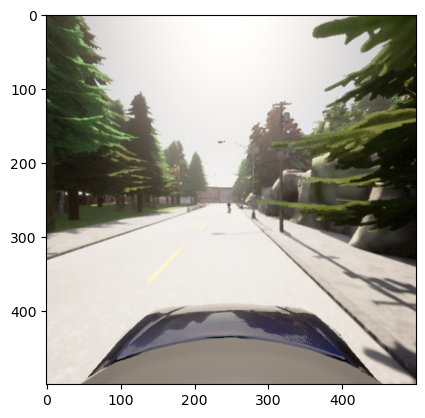

In [8]:
img = Image.open("E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//train//rgb-front//000000.jpg")
plt.imshow(img)
plt.show()
# plt.axis('off')

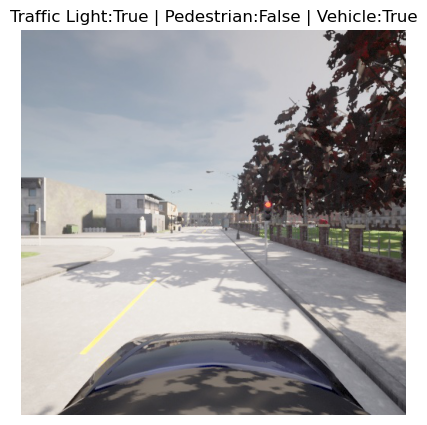

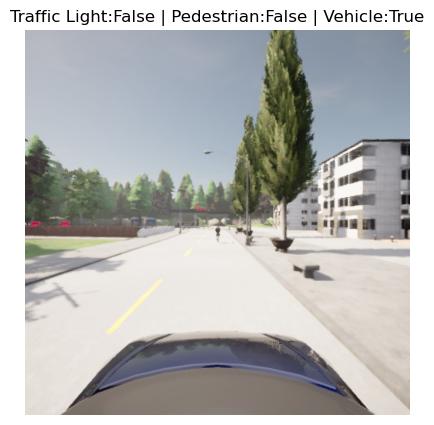

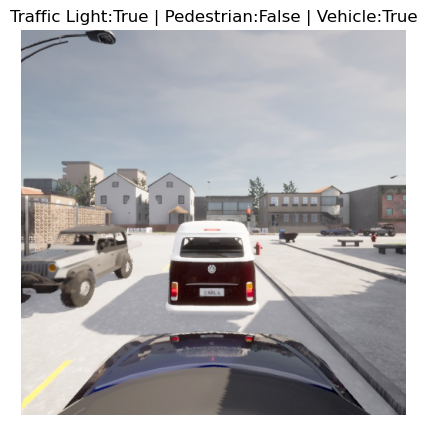

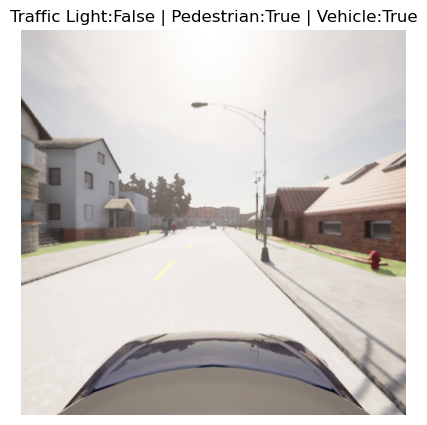

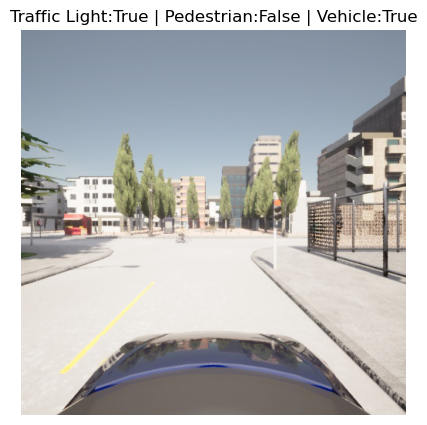

In [9]:
# Randomly selecting 5 Images from the training set and visualizing them
train_labels_images_path = "E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//train//rgb-front//"
random_samples = train_labels.sample(5)
# random_samples
for idx, row in random_samples.iterrows():
    frame = str(row['frame']).zfill(6)
    
    # Image path
    img_path = f'{train_labels_images_path}//{frame}.jpg'

    #Opening image
    img = Image.open(img_path)
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(
        f"Traffic Light:{row['has_traffic_light']} | "
        f"Pedestrian:{row['has_pedestrian']} | "
        f"Vehicle:{row['has_vehicle']}"
    )
    plt.axis('off')

Exercise 3.5: Train Three Binary Classifiers

In [10]:
# ! pip install torchvision

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

In [12]:
#Enabeing GPU 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


# Defining the dataset

In [13]:
class CarlaDataset(Dataset):
    def __init__(self, csv_file, img_dir, label_column, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]
        frame = str(row['frame']).zfill(6)
        img_path = f"{self.img_dir}/{frame}.jpg"
        image = Image.open(img_path).convert('RGB')
        label = float(row[self.label_column])
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Dataset class defined ✅')

Dataset class defined ✅


In [14]:
path = "E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3"

In [15]:
path_save = "E://OVGU_NOTES//Machine_Learning_Safety//assignment"

Training Vehicle Classifier...
Epoch 1/5 — Train Loss: 0.3291 | Val Loss: 0.6133
Epoch 2/5 — Train Loss: 0.2311 | Val Loss: 0.3835
Epoch 3/5 — Train Loss: 0.1963 | Val Loss: 0.2814
Epoch 4/5 — Train Loss: 0.1738 | Val Loss: 0.3070
Epoch 5/5 — Train Loss: 0.1522 | Val Loss: 0.3179


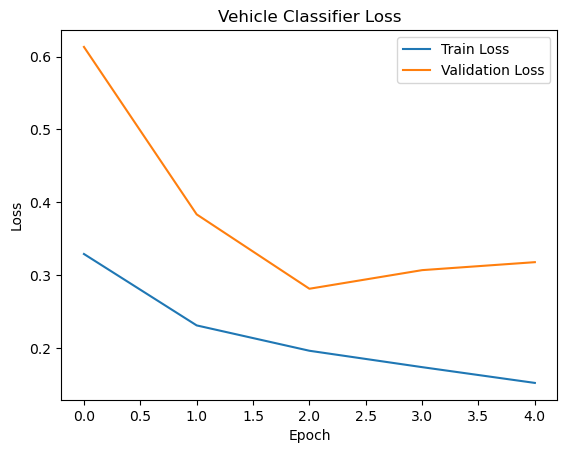

In [16]:


print('Training Vehicle Classifier...')

train_dataset = CarlaDataset(f'{path}//train//labels.csv',      f'{path}//train//rgb-front',      'has_vehicle', transform)
val_dataset   = CarlaDataset(f'{path}//validation//labels.csv', f'{path}//validation//rgb-front', 'has_vehicle', transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

model_vehicle = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_vehicle.fc = nn.Linear(model_vehicle.fc.in_features, 1)
model_vehicle = model_vehicle.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_vehicle.parameters(), lr=0.001)

train_losses, val_losses = [], []

for epoch in range(5):
    model_vehicle.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model_vehicle(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model_vehicle.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            outputs = model_vehicle(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1}/5 — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Vehicle Classifier Loss')
plt.legend()
plt.show()

In [18]:
torch.save(model_vehicle.state_dict(), f"{path_save}//vehicle.pth")

print("Model vehicle saved successfully!")

Model vehicle saved successfully!


Training Pedestrian Classifier...
Epoch 1/5 — Train Loss: 0.5324 | Val Loss: 0.6021
Epoch 2/5 — Train Loss: 0.4446 | Val Loss: 0.6864
Epoch 3/5 — Train Loss: 0.3835 | Val Loss: 0.8137
Epoch 4/5 — Train Loss: 0.3166 | Val Loss: 0.6524
Epoch 5/5 — Train Loss: 0.2830 | Val Loss: 0.7550


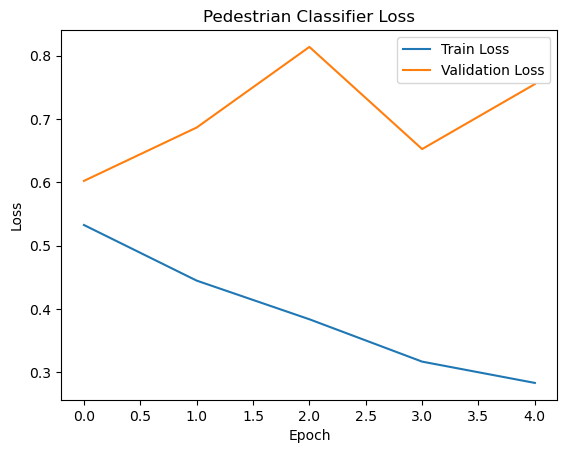

In [19]:
print('Training Pedestrian Classifier...')

train_dataset = CarlaDataset(f'{path}//train//labels.csv',      f'{path}//train//rgb-front',      'has_pedestrian', transform)
val_dataset   = CarlaDataset(f'{path}//validation//labels.csv', f'{path}//validation//rgb-front', 'has_pedestrian', transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

model_pedestrian = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_pedestrian.fc = nn.Linear(model_pedestrian.fc.in_features, 1)
model_pedestrian = model_pedestrian.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_pedestrian.parameters(), lr=0.001)

train_losses, val_losses = [], []

for epoch in range(5):
    model_pedestrian.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model_pedestrian(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model_pedestrian.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            outputs = model_pedestrian(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1}/5 — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Pedestrian Classifier Loss')
plt.legend()
plt.show()

In [20]:
torch.save(model_pedestrian.state_dict(), f"{path_save}//pedestrian.pth")

print("Model pedestrian saved successfully!")

Model pedestrian saved successfully!


Training Traffic Light Classifier...
Epoch 1/5 — Train Loss: 0.1838 | Val Loss: 0.1150
Epoch 2/5 — Train Loss: 0.0998 | Val Loss: 0.1883
Epoch 3/5 — Train Loss: 0.0643 | Val Loss: 0.1257
Epoch 4/5 — Train Loss: 0.0499 | Val Loss: 0.0783
Epoch 5/5 — Train Loss: 0.0442 | Val Loss: 0.0736


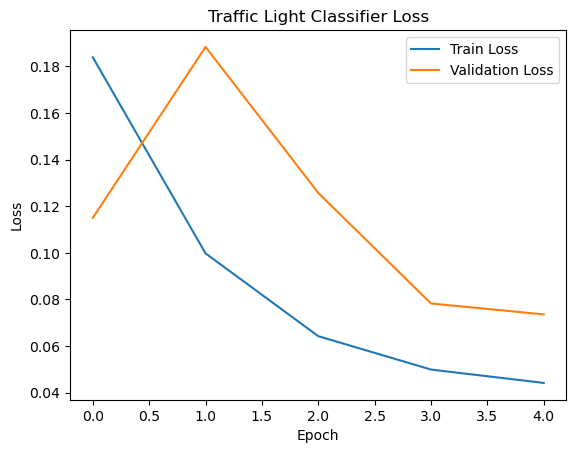

In [21]:
print('Training Traffic Light Classifier...')

train_dataset = CarlaDataset(f'{path}//train//labels.csv',      f'{path}//train//rgb-front',      'has_traffic_light', transform)
val_dataset   = CarlaDataset(f'{path}//validation//labels.csv', f'{path}//validation//rgb-front', 'has_traffic_light', transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

model_traffic = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_traffic.fc = nn.Linear(model_traffic.fc.in_features, 1)
model_traffic = model_traffic.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_traffic.parameters(), lr=0.001)

train_losses, val_losses = [], []

for epoch in range(5):
    model_traffic.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model_traffic(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model_traffic.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            outputs = model_traffic(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1}/5 — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Traffic Light Classifier Loss')
plt.legend()
plt.show()

In [22]:
torch.save(model_traffic.state_dict(), f"{path_save}//traffic.pth")

print("Model traffic saved successfully!")

Model traffic saved successfully!


In [23]:
results = {}

for model, name, col in [
    (model_vehicle,    'Vehicle',       'has_vehicle'),
    (model_pedestrian, 'Pedestrian',    'has_pedestrian'),
    (model_traffic,    'Traffic Light', 'has_traffic_light'),
]:
    test_dataset = CarlaDataset(f'{path}//test//labels.csv', f'{path}//test//rgb-front', col, transform)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    results[name] = {
        'accuracy':  accuracy_score(all_labels,  all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall':    recall_score(all_labels,    all_preds),
        'f1':        f1_score(all_labels,        all_preds),
    }
    print(f'\n{name}:')
    for metric, val in results[name].items():
        print(f'  {metric}: {val:.4f}')


Vehicle:
  accuracy: 0.8631
  precision: 0.8852
  recall: 0.9393
  f1: 0.9114

Pedestrian:
  accuracy: 0.8200
  precision: 0.6381
  recall: 0.1898
  f1: 0.2926

Traffic Light:
  accuracy: 0.9600
  precision: 0.9621
  recall: 0.9830
  f1: 0.9724


               accuracy  precision  recall      f1
Vehicle          0.8631     0.8852  0.9393  0.9114
Pedestrian       0.8200     0.6381  0.1898  0.2926
Traffic Light    0.9600     0.9621  0.9830  0.9724


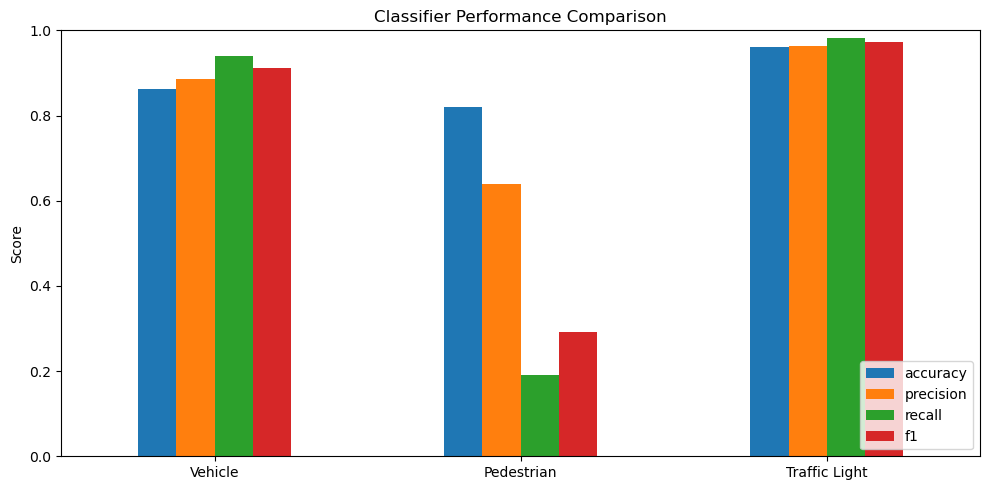

In [24]:
df = pd.DataFrame(results).T
print(df.round(4))

df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
plt.title('Classifier Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Model saved successfully!
